# Proyecto 1 - Mariposas
Materia: Procesamiento Digital de Señales

Grupo: 03

Equipo: 02

### Integrantes:
* Espinoza Matamoros Percival Ulises
* Lugo Manzano Rodrigo
* García Cortés Adolfo de Jésus


## Importacion y Configuracion Bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Implementación de la FFT

In [16]:
def inversion_bits(x):
    N = len(x)
    num_bits = int(np.log2(N))
    x_invertido = np.zeros(N, dtype=complex)

    for i in range(N):
        indice_invertido = 0
        for j in range(num_bits):
            # Colocar en la última posición el bit de interes y obtenerlo
            if (i >> j) & 1:
                # Nuevo Bit
                indice_invertido |= 1 << (num_bits - 1 - j)
        x_invertido[indice_invertido] = x[i]

    return x_invertido

In [15]:
def verificacion_tamano(x):
    N = len(x)
    n = np.log2(N)

    # Evaluando si es potencia de 2
    if not n.is_integer():
        n = int(np.ceil(n))
        N_nuevo = 2 ** n
        # Padding hasta forzar a que N sea una potencia de 2
        x = np.pad(x, (0, N_nuevo - N), mode='constant')
    return x

In [5]:
def fft(x:np.ndarray) -> np.ndarray:
    # Ordenamiento por inversión de bits
    x = verificacion_tamano(x)
    # Inversión de bits
    x = inversion_bits(x)
    N = len(x)

    # Factores W
    W = np.exp(-1j * (2 * np.pi / N) * np.arange(N//2))

    # Tamaño de bloque inicial
    tamano_bloque = 2
    while tamano_bloque <= N:
        mitad_bloque = tamano_bloque // 2

        salto = N // tamano_bloque

        w = W[0 : mitad_bloque * salto : salto]


        for inicio_bloque in range(0, N, tamano_bloque):
            for mariposa in range(mitad_bloque):
                # Obtencion de los indices de los nodos superior e inferior
                indice_superior = inicio_bloque + mariposa
                indice_inferior = indice_superior + mitad_bloque

                # Obtención del W
                omega = w[mariposa]

                # Resolucion de Mariposas
                termino_intermedio = omega * x[indice_inferior]
                nodo_superior =x[indice_superior] + termino_intermedio
                nodo_inferior =x[indice_superior] - termino_intermedio

                # Actualización de los nodos en el arreglo
                x[indice_superior] = nodo_superior
                x[indice_inferior] = nodo_inferior

        tamano_bloque *= 2

    return x

## Pruebas y Comparación con Numpy


--- Escenario: N = 256 ---
Error máximo entre implementaciones: 6.16740e-14


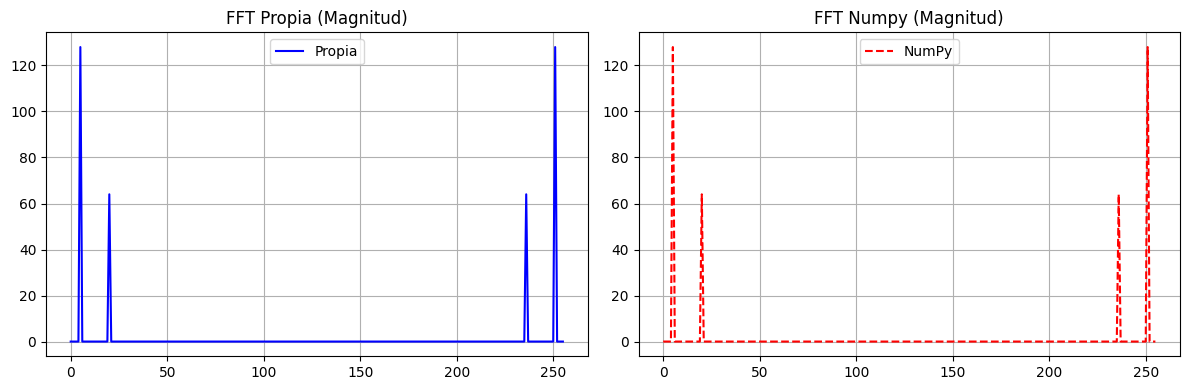


--- Escenario: N = 1024 ---
Error máximo entre implementaciones: 3.34990e-13


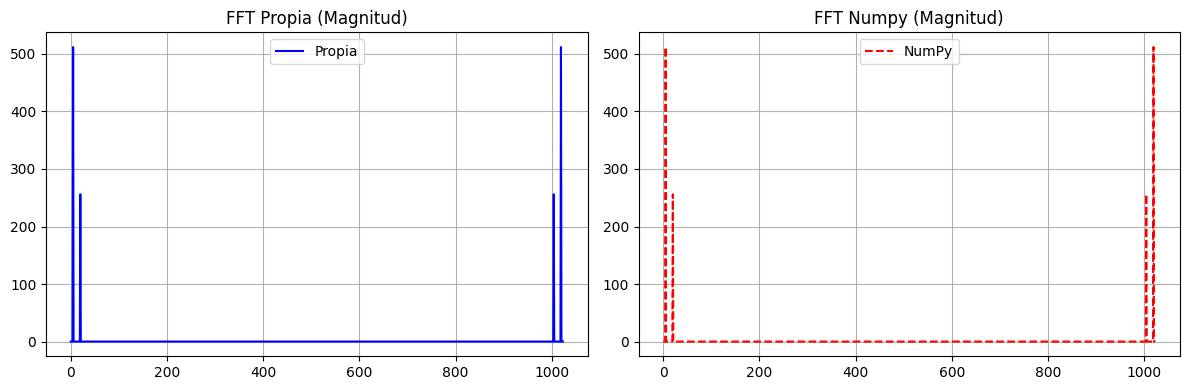


--- Escenario: N = 300 ---
Error máximo entre implementaciones: 5.12380e-14


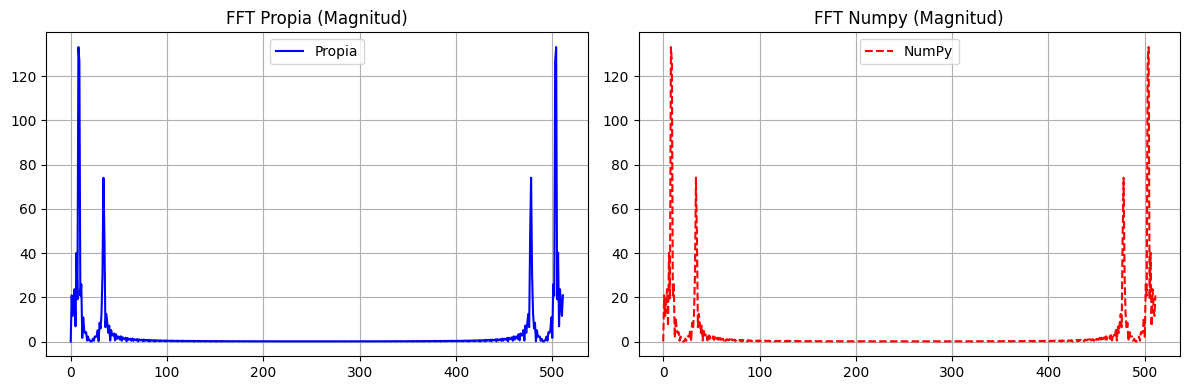


--- Escenario: N = 1000 ---
Error máximo entre implementaciones: 3.32668e-13


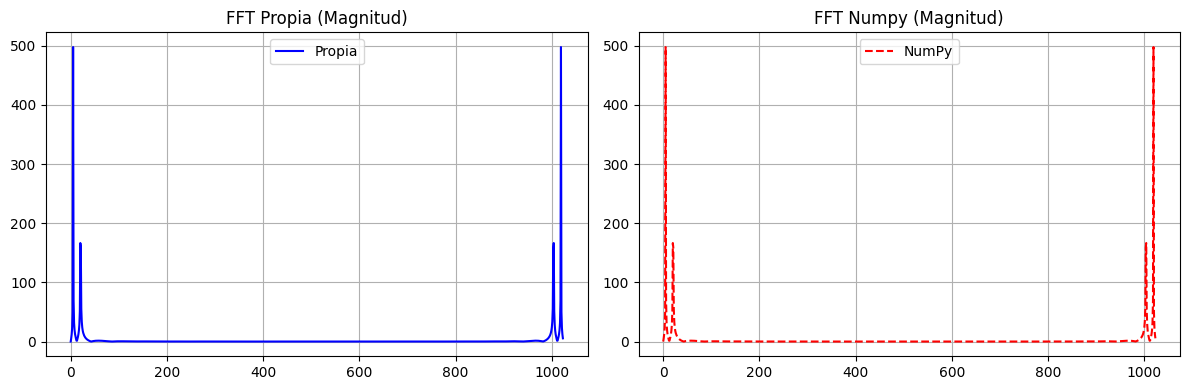

In [17]:
# Funcion para automatizar las comparaciones
def comparar_fft(N):
    print(f"\n--- Escenario: N = {N} ---")

    # Señal de prueba: suma de dos ondas senoidales
    t = np.linspace(0, 1, N, endpoint=False)
    f1, f2 = 5, 20
    x = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

    # Usando la FFT que implementamos
    x_propia = x.copy()
    X_propia = fft(x_propia)

    # FFT Numpy con el padding que realiza la FFT que implementamos
    n = np.log2(N)
    if not n.is_integer():
        N_nuevo = 2 ** int(np.ceil(n))
        x_np = np.pad(x, (0, N_nuevo - N), mode='constant')
    else:
        x_np = x

    X_np = np.fft.fft(x_np)

    # Calcular error
    error_maximo = np.max(np.abs(X_propia - X_np))
    print(f"Error máximo entre implementaciones: {error_maximo:.5e}")

    # Graficas de Resultados
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.title(f"FFT Propia (Magnitud)")
    plt.plot(np.abs(X_propia), label='Propia', color='blue')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title(f"FFT Numpy (Magnitud)")
    plt.plot(np.abs(X_np), label='NumPy', color='red', linestyle='dashed')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Escenarios
tamanos_prueba = [256, 1024, 300, 1000]
for N in tamanos_prueba:
    comparar_fft(N)


In [19]:
# Funcion para automatizar las comparaciones + Impresión de Resultados
def comparar_fft_detalle(N, f1=5, f2=20, a1=1.0, a2=0.5):
    print(f"\n--- Escenario: N = {N} ---")

    # Señal de Prueba: Suma de Dos Senoidales
    t = np.linspace(0, 1, N, endpoint=False)
    x = a1 * np.sin(2 * np.pi * f1 * t) + a2 * np.sin(2 * np.pi * f2 * t)

    # Usando la FFT que implementamos
    x_propia = x.copy()
    X_propia = fft(x_propia)

    # Usando la FFT de Numpy + Mismo Padding
    n = np.log2(N)
    if not n.is_integer():
        N_nuevo = 2 ** int(np.ceil(n))
        x_np = np.pad(x, (0, N_nuevo - N), mode='constant')
    else:
        x_np = x

    X_np = np.fft.fft(x_np)

    # Calculo del error
    error_maximo = np.max(np.abs(X_propia - X_np))
    print(f"Error máximo entre implementaciones: {error_maximo:.5e}\n")

    # Impresión de valores
    print("Comparación de los primeros 10 valores (Magnitud):")
    print(f"{'-'*45}")
    print(f"{'Índice':<8} | {'FFT Propia':<15} | {'FFT NumPy':<15}")
    print(f"{'-'*45}")
    for i in range(min(10, len(X_propia))):
        print(f"{i:<8} | {np.abs(X_propia[i]):<15.5f} | {np.abs(X_np[i]):<15.5f}")
    print(f"{'-'*45}\n")

    # Gráficas
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("FFT Propia (Magnitud)")
    plt.plot(np.abs(X_propia), label='Propia', color='blue')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("FFT Numpy (Magnitud)")
    plt.plot(np.abs(X_np), label='NumPy', color='red', linestyle='dashed')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


--- Escenario: N = 256 ---
Error máximo entre implementaciones: 6.16740e-14

Comparación de los primeros 10 valores (Magnitud):
---------------------------------------------
Índice   | FFT Propia      | FFT NumPy      
---------------------------------------------
0        | 0.00000         | 0.00000        
1        | 0.00000         | 0.00000        
2        | 0.00000         | 0.00000        
3        | 0.00000         | 0.00000        
4        | 0.00000         | 0.00000        
5        | 128.00000       | 128.00000      
6        | 0.00000         | 0.00000        
7        | 0.00000         | 0.00000        
8        | 0.00000         | 0.00000        
9        | 0.00000         | 0.00000        
---------------------------------------------



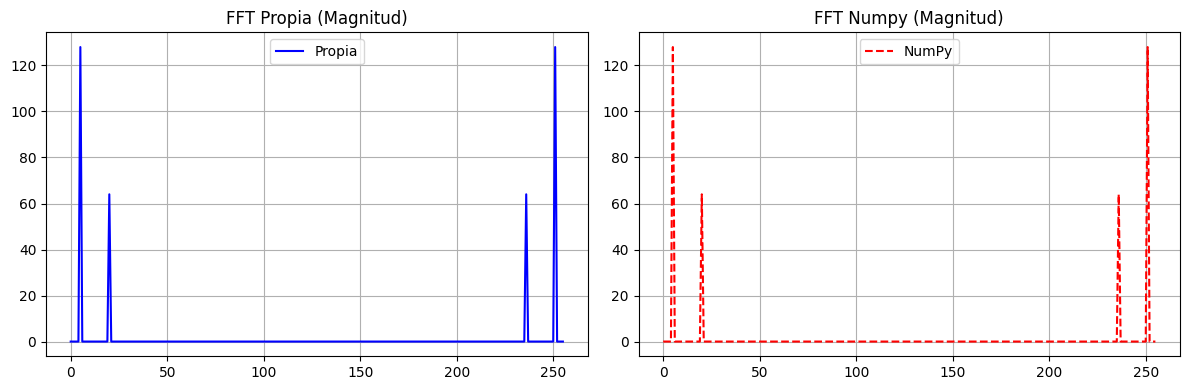

In [8]:
# Prueba con N = 256 (Potencia de 2)
comparar_fft_detalle(256)


--- Escenario: N = 1024 ---
Error máximo entre implementaciones: 3.34990e-13

Comparación de los primeros 10 valores (Magnitud):
---------------------------------------------
Índice   | FFT Propia      | FFT NumPy      
---------------------------------------------
0        | 0.00000         | 0.00000        
1        | 0.00000         | 0.00000        
2        | 0.00000         | 0.00000        
3        | 0.00000         | 0.00000        
4        | 0.00000         | 0.00000        
5        | 512.00000       | 512.00000      
6        | 0.00000         | 0.00000        
7        | 0.00000         | 0.00000        
8        | 0.00000         | 0.00000        
9        | 0.00000         | 0.00000        
---------------------------------------------



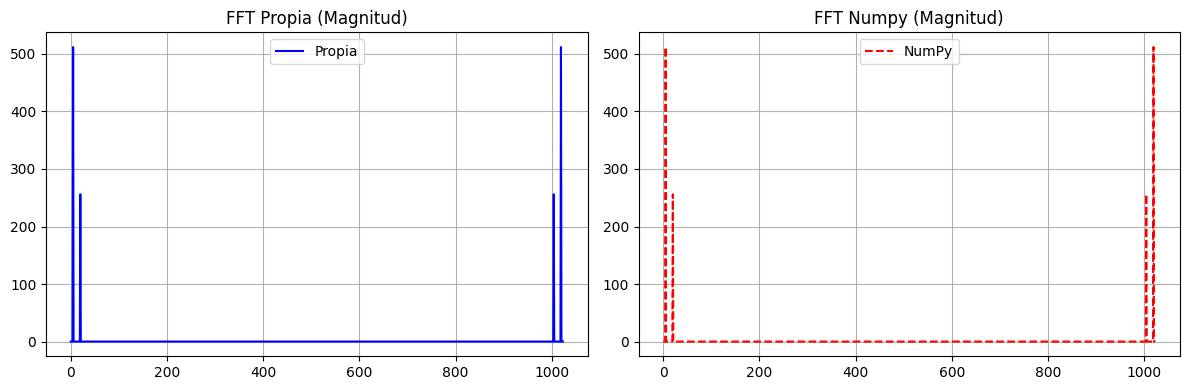

In [9]:
# Prueba con N = 1024 (Potencia de 2)
comparar_fft_detalle(1024)


--- Escenario: N = 300 ---
Error máximo entre implementaciones: 5.12380e-14

Comparación de los primeros 10 valores (Magnitud):
---------------------------------------------
Índice   | FFT Propia      | FFT NumPy      
---------------------------------------------
0        | 0.00000         | 0.00000        
1        | 20.91532        | 20.91532       
2        | 11.59393        | 11.59393       
3        | 16.64926        | 16.64926       
4        | 23.67508        | 23.67508       
5        | 6.89531         | 6.89531        
6        | 40.13554        | 40.13554       
7        | 19.08111        | 19.08111       
8        | 133.19396       | 133.19396      
9        | 126.79836       | 126.79836      
---------------------------------------------



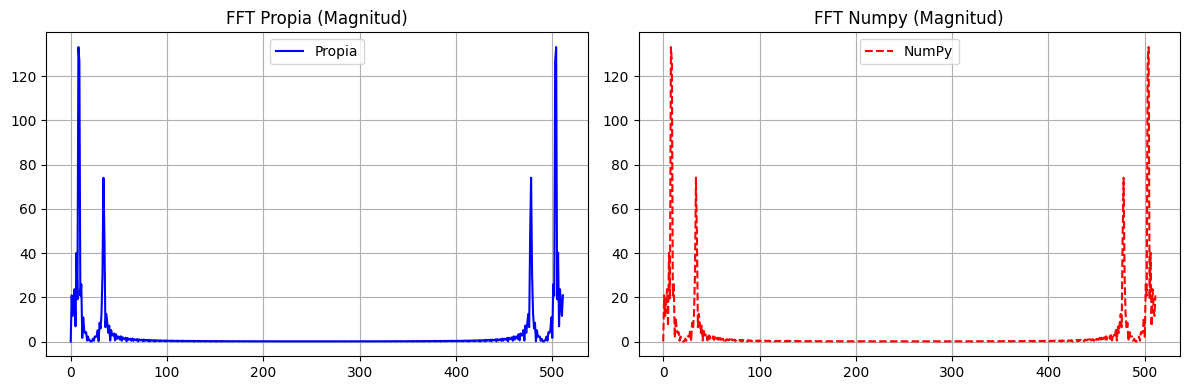

In [10]:
# Prueba con N = 300 (No es potencia de 2)
comparar_fft_detalle(300)

### Pruebas de la FFT dado los valores de dos senoidales



--- Escenario: N = 150 ---
Error máximo entre implementaciones: 4.97380e-14

Comparación de los primeros 10 valores (Magnitud):
---------------------------------------------
Índice   | FFT Propia      | FFT NumPy      
---------------------------------------------
0        | 0.00000         | 0.00000        
1        | 10.40216        | 10.40216       
2        | 5.60078         | 5.60078        
3        | 7.63157         | 7.63157        
4        | 9.98402         | 9.98402        
5        | 2.55595         | 2.55595        
6        | 12.10518        | 12.10518       
7        | 3.98667         | 3.98667        
8        | 11.20206        | 11.20206       
9        | 10.95564        | 10.95564       
---------------------------------------------



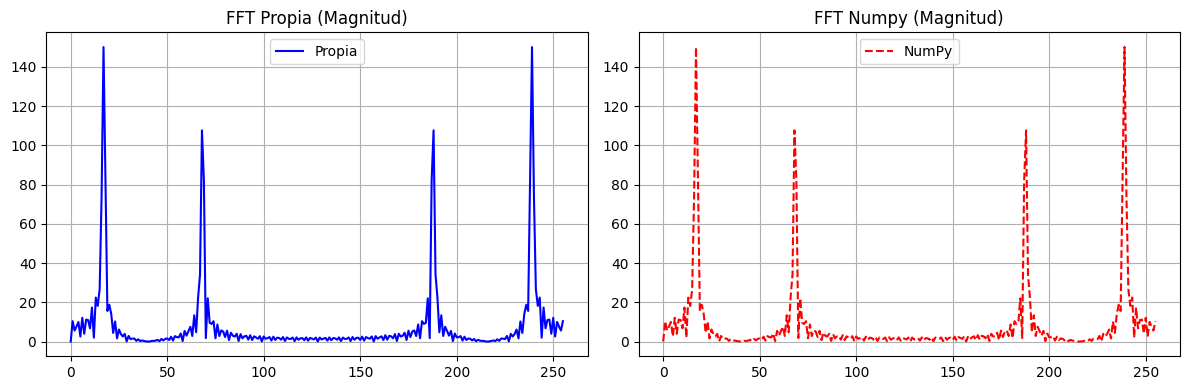

In [21]:
# Parámetros para probar la FFT
N_personalizado = 150
frecuencia_1 = 10
frecuencia_2 = 40
amplitud_1 = 2.0
amplitud_2 = 1.5

comparar_fft_detalle(
    N=N_personalizado,
    f1=frecuencia_1,
    f2=frecuencia_2,
    a1=amplitud_1,
    a2=amplitud_2
)